# Imports

In [1]:
import os
import sys

In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{bm}", # Recomendado para negritas matemáticas
})

In [3]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [4]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [6]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

### Functions

### Load data

In [7]:
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88, 'disk_name': 'Elias27'}
data = Elias27

# UVtable
dir = "../../data/uvtable/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

geom = Geometry(inc, pa, dra, ddec)

In [8]:
q = np.hypot(uvtable['u'], uvtable['v'])
q_min = np.min(q)
q_max = np.max(q)

Rmax = 2*rout
import math 
N = math.floor(5* Rmax/rad_to_arcsec * q_max)

print("N =", N)
print("Rmax =", Rmax)

N = 1113
Rmax = 3.76


In [9]:
cellsize = 2*Rmax/N
cellsize 

0.006756513926325247

#### UVcoverage

ValueError: 'c' argument has 36803272 elements, which is inconsistent with 'x' and 'y' with size 1238769.

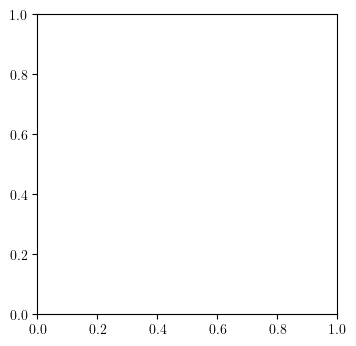

In [143]:
fig = plt.figure(figsize=(4, 4))

ax = fig.add_axes([0.1, 0.1, 0.75, 0.75]) 

log_abs_Vis = np.log(np.abs(Vis))
v_min_color = -10
v_max_color = -2
zoom_factor = 1

scatter = ax.scatter(-u, 
                     -v, 
                     c=log_abs_Vis,
                     marker=',',
                     alpha=0.5,
                     cmap='magma',
                     vmin=v_min_color,
                     vmax=v_max_color)

ax.set_xlim(1.5e7 / zoom_factor, -1.5e7 / zoom_factor)
ax.set_ylim(-1.5e7 / zoom_factor, 1.5e7/ zoom_factor) 


ax.set_xlabel(r'u [$\lambda$]', size=14)
ax.set_ylabel(r'v [$\lambda$]', size=14)
ax.tick_params(axis='both',    # Puede ser 'x', 'y' o 'both'
               which='major',  # Puede ser 'major', 'minor' o 'both'
               labelsize=12,   # Tamaño de la FUENTE (los números)
               length=5,      # Longitud de la MARCA (la línea)
               width=2)

ax.set_aspect('equal', adjustable='box') 

cb_ax = fig.add_axes([0.87, 0.1, 0.03, 0.75]) 

cbar = plt.colorbar(scatter, cax=cb_ax)
cbar.set_label(r'log$\|V\|$ [Jy]', size=14)


plt.show()

#### Power spectrum

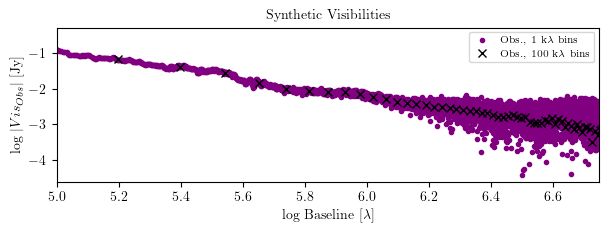

In [10]:
# Analize power spectrum.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = uvtable['u'], uvtable['v']
Vis = uvtable['vis']
Weights = uvtable['weights']

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V))

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V))


lgx = np.log10(np.geomspace(np.sort(baselines)[1], baselines.max(), 1000))


cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

plt.figure(figsize=(7, 2))
plt.plot(logx, logy, marker=ms[0], ls='None', c ='purple', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|$ [Jy]', size = 10)
plt.legend(loc = 'best', fontsize = 'x-small')
plt.title("Synthetic Visibilities", size = 10)
#plt.ylim(-8, 0)
plt.xlim(5, 6.75)
plt.show()

Power spectrum fit: m =  -2 , c =  141253754.46227553


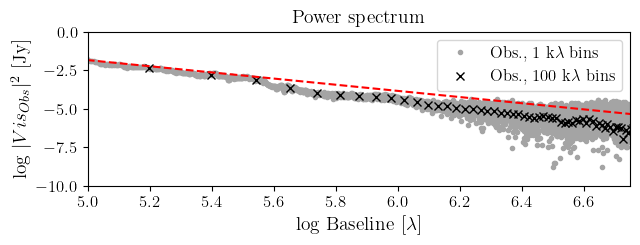

In [10]:
# Analize power spectrum.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = uvtable['u'], uvtable['v']
Vis = uvtable['vis']
Weights = uvtable['weights']

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V)**2)

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V)**2)

def linear_power_spectrum(logx, m, c):
    return m*logx + np.log10(c)


lgx = np.log10(np.geomspace(np.sort(baselines)[1], baselines.max(), 1000))


cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

plt.figure(figsize=(7, 2))
plt.plot(logx, logy, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

m = -2
p = -1.85
logc = p - 5*m
c = 10**logc
print("Power spectrum fit: m = ", m, ", c = ", c)
lgy = linear_power_spectrum(lgx, m, c)
plt.plot(lgx, lgy, c='red', ls='--')

plt.xlabel(r'log Baseline [$\lambda$]', size = 14)
plt.ylabel(r'log $|Vis_{Obs}|^{2}$ [Jy]', size = 14)
plt.legend(loc = 'best', fontsize = 12)
plt.title("Power spectrum", size = 14)
plt.tick_params(axis='both', which='both', labelsize=12)
plt.ylim(-10, 0)
plt.xlim(5, 6.75)
plt.show()

In [12]:
p0 = p 
m0 = m
c0 = c
initial = {'m': m0, 'c': c0, 'l' : 10**4}

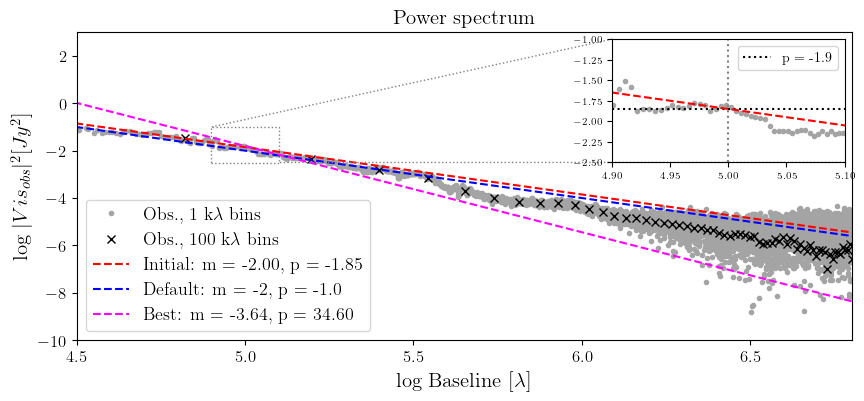

In [16]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(logx, logy, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
ax.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

lgy = linear_power_spectrum(lgx, m0, c0)
lgy2 = linear_power_spectrum(lgx, -2, 10**8)

best ={'m': -3.6400081642338615, 'c': 2.4931604784432084e+16, 'l': 57490.1215238161}
lgy3 = linear_power_spectrum(lgx, best['m'], best['c'])
ax.plot(lgx, lgy, c='red', ls='--', label='Initial: m = {:.2f}, p = {:.2f}'.format(m, p))
ax.plot(lgx, lgy2, c='blue', ls='--', label='Default: m = -2, p = -1.0')
ax.plot(lgx, lgy3, c='magenta', ls='--', label='Best: m = {:.2f}, p = {:.2f}'.format(best['m'], np.log10(best['c']) - 5*best['m']))


ax.set_xlabel(r'log Baseline [$\lambda$]', size=15)
ax.set_ylabel(r'log $|Vis_{obs}|^{2} [Jy^2]$', size=15)
ax.legend(loc='lower left', fontsize=13)
ax.tick_params(axis='both', which='both', labelsize=12)
ax.set_title("Power spectrum", size=15)
ax.set_ylim(-10, 3) 
ax.set_xlim(4.5, 6.8)

axins = inset_axes(ax, width="30%", height="40%", loc=1)

axins.plot(logx, logy, c=cs[0], marker=ms[0], ls='None')
axins.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None')
axins.axhline(p, c='black', ls=':', label='p = {:.1f}'.format(p))
axins.axvline(5, c='gray', ls=':')
axins.plot(lgx, lgy, c='red', ls='--')
axins.legend(fontsize=10)

axins.set_xlim(4.9, 5.1)
axins.set_ylim(-2.5, -1)

axins.tick_params(labelsize=7)

mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5", ls=':')

plt.show()

### Dirty image

In [64]:
frank2d0 = Frank2D(N, Rmax)

In [65]:
frank2d0.dx

0.006756513926325247

In [66]:

print(f"-> q_min data: {q_min}, q_max data: {q_max}")

-> q_min data: 10316.430545274563, q_max data: 12213086.334906872


In [67]:
Un = frank2d0.FT.uv_points[0]
Vn = frank2d0.FT.uv_points[1]

Qn = np.sort(np.hypot(Un, Vn))

q_min_f2d = Qn[1]
q_max_f2d = Qn[-1]
print(f"-> q_min frank2d: {q_min_f2d}, q_max frank2d: {q_max_f2d}")

-> q_min frank2d: 27428.83061796494, q_max frank2d: 21567364.688537993


In [68]:
frank2d0.process_vis(uvtable)

===>  Setting gridded data...


In [69]:
u, v = frank2d0.gridded_data['u'], frank2d0.gridded_data['v']
vis = frank2d0.gridded_data['vis']
weights = frank2d0.gridded_data['weights']

In [70]:
Plot_f2d0 = Plot(frank2d0, geom)

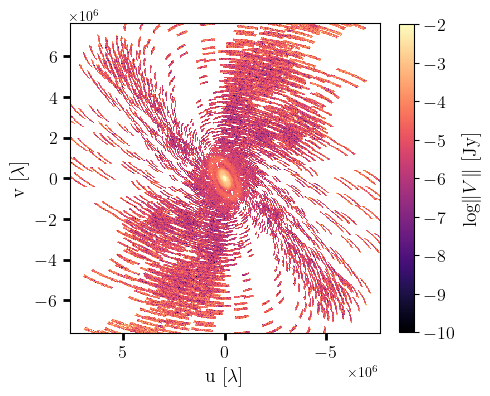

In [71]:
Plot_f2d0.visibility(kind = 'input', fig_size=5, zoom =2, title='')

In [72]:
dx = frank2d0.dx/rad_to_arcsec
dy = frank2d0.dy/rad_to_arcsec
pixel_area_in_sr = dx * dy
I_syn_full_Jy_per_sr = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(vis.reshape(N,N)))).real / pixel_area_in_sr
I_syn_full_Jy_per_pixel = I_syn_full_Jy_per_sr * pixel_area_in_sr

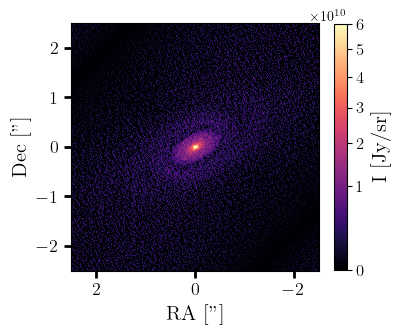

In [73]:
import matplotlib.colors as colors
norm = colors.PowerNorm(gamma = 0.6, vmax=6e10, vmin = 0)
plt.figure(figsize=(4,4))
plt.imshow(
            I_syn_full_Jy_per_sr, 
            extent=[frank2d0.Rmax, -frank2d0.Rmax, -frank2d0.Rmax, frank2d0.Rmax],
            norm=norm, 
            cmap = 'magma',
            )

plt.gca().invert_yaxis()
plt.xlim(Rmax/1.5, -Rmax/1.5)
plt.ylim(-Rmax/1.5, Rmax/1.5)
#plt.title('Mock data', size =10)
plt.xlabel(r'RA ["]', size=15, weight='extra bold')
plt.ylabel('Dec ["]', size=15, weight='extra bold')

cbar = plt.colorbar(shrink=0.8)
cbar.set_label(label='I [Jy/sr]', size=15)
cbar.ax.tick_params(labelsize=12)
ax = plt.gca()
ax.tick_params(axis='both', 
               which='major',
               labelsize=13,
               length=5,
               width=2)

### Frank2D

In [47]:
N

1113

In [48]:
Rmax

3.76

In [74]:
frank2d2 = Frank2D(N, Rmax)

In [75]:
frank2d2.dx

0.006756513926325247

In [76]:
frank2d2.process_vis(uvtable)

===>  Setting gridded data...


In [77]:
frank2d2.fit(rtol = 1e-10, precond_type='ilu', kernel_params=initial)

===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2, 'c': 141253754.46227553, 'l': 10000}
===>  Creating sparse linear system...


        +  Kernel = 0.05  min |  3.01 seconds
        +   CSC = 0.00  min |  0.00 seconds
        +  ILU = 0.01  min |  0.32 seconds
        +  Building system = 0.06  min |  3.37 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 1/50000 [00:00<3:04:55,  4.51 iterations/s]


            +  BiCGStab = 0.00  min |  0.22 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.005988209486557158,
 'iterations': 1,
 'maxiter': 50000,
 'preconditioner_method': 'ilu',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.30  min |  17.90 seconds
--> times building full visibility model = 0.30  min |  17.93 seconds


In [53]:
#frank2d2.fit(data = uvtable, rtol = 1e-10)

In [78]:
Plot_ = Plot(frank2d2, geom)

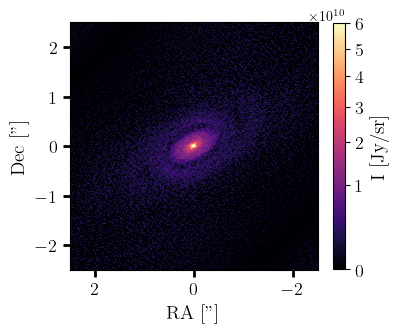

In [79]:
Plot_.intensity(vmax=6e10, gamma = 0.6, zoom = 1.5, title = '', fig_size = 4)

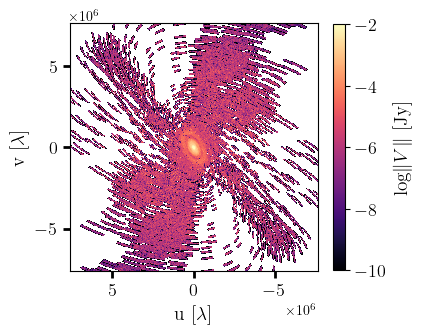

In [80]:
Plot_.visibility(fig_size=4, title='', zoom=2)

###  Best

In [22]:
p = -1.85 # before -2
m = -2 # before -2

initial_guess = {'p': p, 'm': m, 'logl': 4}

In [23]:
frank2d2.search_MAP(initial_guess= initial_guess, N = 50)

Using existing visibility data...
===>  Searching for MAP...
        + Initial guess:  {'p': -1.85, 'm': -2, 'logl': 4}
Fitting the visibilities with Frank2D with 2DFT...


 + Time to preprocess the visibilities: 808.54 seconds
Setting the initial guess...
Optimizing the posterior...
 + Time to optimize the posterior: 865.31 seconds


In [24]:
frank2d2.MAP

{'m': -3.6400081642338615, 'c': 2.4931604784432084e+16, 'l': 57490.1215238161}

In [58]:
frank2d2.MAPEstimator.Qmax

646503.7376660071

### Frank2D with best values

In [61]:
# import pickles files

#import pickle
#with open("../../data/exp/N_opt/Elias27_optGPU_Nopt80.pkl", 'rb') as handle:
#    f2d_obj = pickle.load(handle)
#    print(f2d_obj.MAP)
#    print(f2d_obj.MAPEstimator.Qmax)

In [9]:
best_N50 = {'m': -3.6400081642338615, 'c': 2.4931604784432084e+16, 'l': 57490.1215238161} #27m59s

maps = [best_N50]
#times =  [36*60 + 54.2]
Qmaxs = [646503.7376660071, 775804.4851992084, 905105.2327324098, 1034405.9802656114]


In [10]:
frank2d3 = Frank2D(N, Rmax)

In [11]:
frank2d3.process_vis(uvtable)

===>  Setting gridded data...


In [12]:
frank2d3.fit(kernel_params = best_N50, rtol = 1e-10, precond_type='ilu') # 1m27s

===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -3.6400081642338615, 'c': 2.4931604784432084e+16, 'l': 57490.1215238161}
===>  Creating sparse linear system...


        +  Kernel = 0.18  min |  10.98 seconds
        +   CSC = 0.00  min |  0.14 seconds
        +  ILU = 0.64  min |  38.53 seconds
        +  Building system = 0.84  min |  50.20 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 10/50000 [00:02<3:53:57,  3.56 iterations/s]


            +  BiCGStab = 0.05  min |  2.84 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of r',
 'final_tol': 0.005988209486557158,
 'iterations': 10,
 'maxiter': 50000,
 'preconditioner_method': 'ilu',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.37  min |  22.23 seconds
--> times building full visibility model = 0.37  min |  22.41 seconds


In [32]:
#frank2d3.fit(data = uvtable, kernel_params = best_N50, rtol = 1e-10) # 1m7s

In [37]:
Plot_3 = Plot(frank2d3, geom)

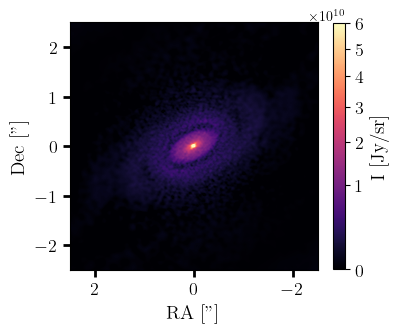

In [45]:
Plot_3.intensity(vmax=6e10, gamma = 0.6, zoom = 1.5, title = r'', fig_size= 4)

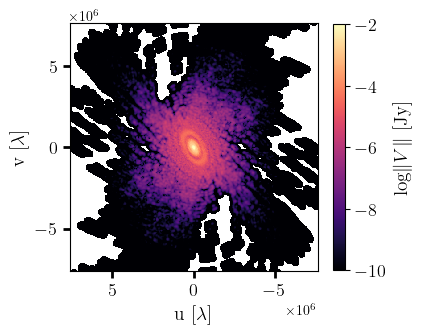

In [35]:
Plot_3.visibility(fig_size=4, zoom = 2,  title = r'')

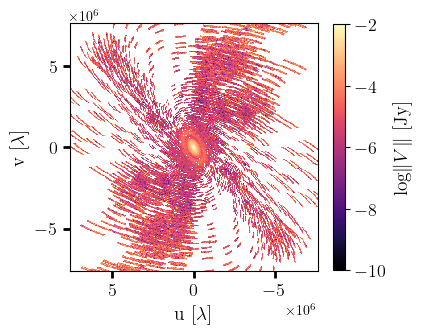

In [36]:
Plot_3.visibility(fig_size=4, zoom = 2,  title = r'', kind='input')

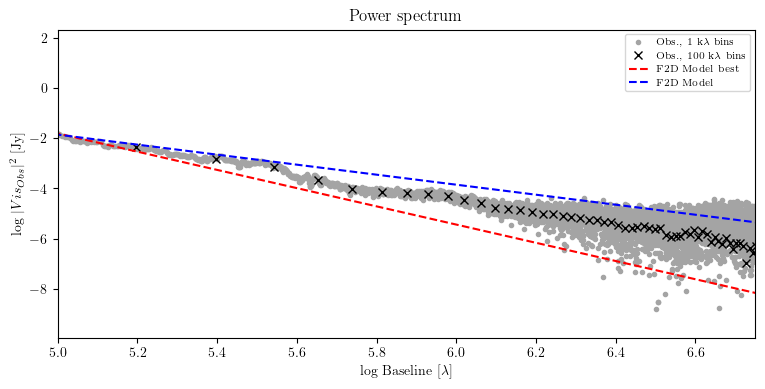

In [49]:
# Analize power spectrum.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = uvtable['u'], uvtable['v']
Vis = uvtable['vis']
Weights = uvtable['weights']

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V)**2)

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V)**2)

def linear_power_spectrum(logx, m, c):
    return m*logx + np.log10(c)


lgx = np.log10(np.geomspace(np.sort(baselines)[1], baselines.max(), 1000))


cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

plt.figure(figsize=(9, 4))
plt.plot(logx, logy, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


lgy_best = linear_power_spectrum(lgx, best_N50['m'], best_N50['c'])
lgy_ = linear_power_spectrum(lgx, m0, c0)

plt.plot(lgx, lgy_best, 'r--', label='F2D Model best')
plt.plot(lgx, lgy_, 'b--', label='F2D Model')

plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|^{2}$ [Jy]', size = 10)
plt.legend(loc = 'best', fontsize = 'x-small')
plt.title("Power spectrum")
#plt.ylim(-8, 0)
plt.xlim(5, 6.75)
plt.show()

## All N_opts

In [11]:
maps = []
Qmaxs = []

import pickle
dir = "../../data/exp/N_opt/"
Nopts =[50, 60, 70, 80, 100]
#import objects
for i in Nopts:
    file_name = dir + "Elias27_optGPU_Nopt" + str(i) + ".pkl"
    with open(file_name, 'rb') as file:
        frank_obj = pickle.load(file)
        maps.append(frank_obj.MAP)
        Qmaxs.append(frank_obj.FT.Qmax.get())

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -3.6400113451471947, 'c': 2.493261287592933e+16, 'l': 57490.11469896575}
===>  Creating sparse linear system...
        +  Kernel = 0.19  min |  11.62 seconds
        +   CSC = 0.00  min |  0.15 seconds
        +  ILU = 0.67  min |  40.32 seconds
        +  Building system = 0.88  min |  52.66 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 9/50000 [00:02<4:21:26,  3.19 iterations/s]


            +  BiCGStab = 0.05  min |  2.83 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.005988209486557158,
 'iterations': 9,
 'maxiter': 50000,
 'preconditioner_method': 'ilu',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.38  min |  22.96 seconds
--> times building full visibility model = 0.39  min |  23.14 seconds


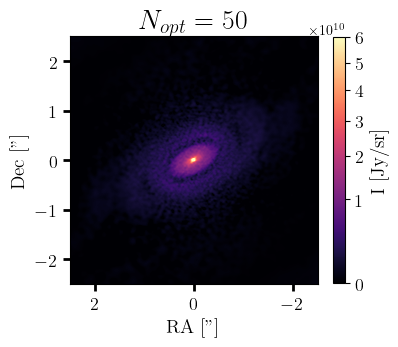

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -3.1249812779281743, 'c': 32319143990925.98, 'l': 50049.142001063956}
===>  Creating sparse linear system...
        +  Kernel = 0.16  min |  9.75 seconds
        +   CSC = 0.00  min |  0.10 seconds
        +  ILU = 0.50  min |  29.73 seconds
        +  Building system = 0.67  min |  40.08 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 6/50000 [00:01<4:22:51,  3.17 iterations/s]


            +  BiCGStab = 0.03  min |  1.90 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.005988209486557158,
 'iterations': 6,
 'maxiter': 50000,
 'preconditioner_method': 'ilu',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.37  min |  22.00 seconds
--> times building full visibility model = 0.37  min |  22.15 seconds


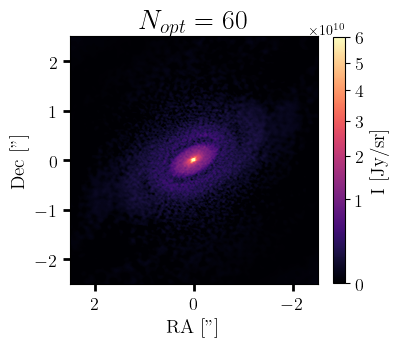

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.754818327094938, 'c': 302752288908.0494, 'l': 46995.70178153139}
===>  Creating sparse linear system...
        +  Kernel = 0.16  min |  9.35 seconds
        +   CSC = 0.00  min |  0.10 seconds
        +  ILU = 0.42  min |  25.14 seconds
        +  Building system = 0.58  min |  35.03 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 6/50000 [00:01<3:51:04,  3.61 iterations/s]


            +  BiCGStab = 0.03  min |  1.67 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of r',
 'final_tol': 0.005988209486557158,
 'iterations': 6,
 'maxiter': 50000,
 'preconditioner_method': 'ilu',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.36  min |  21.84 seconds
--> times building full visibility model = 0.37  min |  21.98 seconds


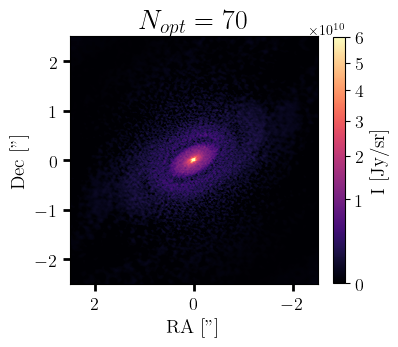

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.486499603701048, 'c': 11640541287.691711, 'l': 47400.5556392564}
===>  Creating sparse linear system...
        +  Kernel = 0.16  min |  9.44 seconds
        +   CSC = 0.00  min |  0.10 seconds
        +  ILU = 0.45  min |  27.11 seconds
        +  Building system = 0.62  min |  37.08 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 6/50000 [00:01<4:17:54,  3.23 iterations/s]


            +  BiCGStab = 0.03  min |  1.86 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.005988209486557158,
 'iterations': 6,
 'maxiter': 50000,
 'preconditioner_method': 'ilu',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.37  min |  22.06 seconds
--> times building full visibility model = 0.37  min |  22.21 seconds


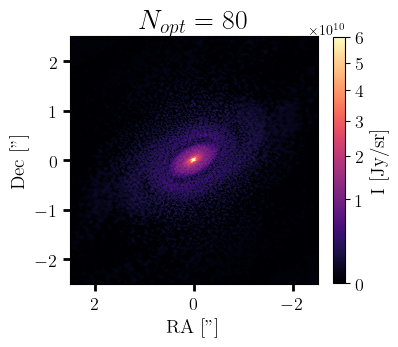

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.978351999347842, 'c': 11659317.0947916, 'l': 38942.79294123683}
===>  Creating sparse linear system...
        +  Kernel = 0.13  min |  7.64 seconds
        +   CSC = 0.00  min |  0.07 seconds
        +  ILU = 0.28  min |  17.09 seconds
        +  Building system = 0.42  min |  25.14 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 5/50000 [00:01<3:29:50,  3.97 iterations/s]


            +  BiCGStab = 0.02  min |  1.26 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of r',
 'final_tol': 0.005988209486557158,
 'iterations': 5,
 'maxiter': 50000,
 'preconditioner_method': 'ilu',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.35  min |  20.81 seconds
--> times building full visibility model = 0.35  min |  20.91 seconds


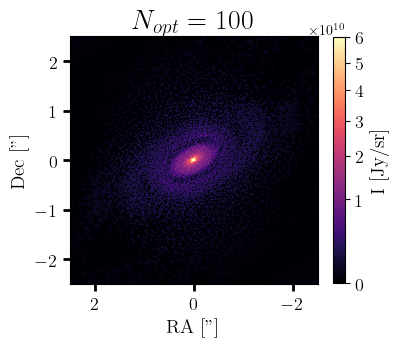

In [13]:
for index in range(len(Nopts)):
        frank_obj = Frank2D(N, Rmax)
        frank_obj.process_vis(uvtable)
        frank_obj.fit(kernel_params = maps[index], rtol = 1e-10, precond_type='ilu')
        Plot_ = Plot(frank_obj, geom)
        Plot_.intensity(vmax=6e10, gamma = 0.6, zoom = 1.5, title = r'$N_{opt}$ = ' + str(Nopts[index]), fig_size= 4)

In [14]:
from frank.utilities import UVDataBinner       

In [15]:
maps

[{'m': -3.6400113451471947,
  'c': 2.493261287592933e+16,
  'l': 57490.11469896575},
 {'m': -3.1249812779281743, 'c': 32319143990925.98, 'l': 50049.142001063956},
 {'m': -2.754818327094938, 'c': 302752288908.0494, 'l': 46995.70178153139},
 {'m': -2.486499603701048, 'c': 11640541287.691711, 'l': 47400.5556392564},
 {'m': -1.978351999347842, 'c': 11659317.0947916, 'l': 38942.79294123683}]

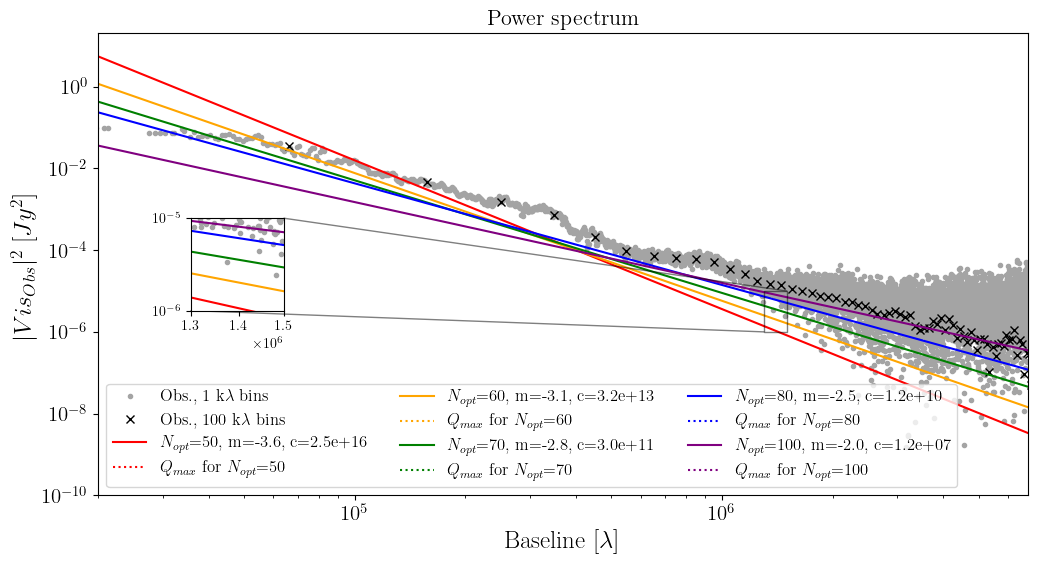

In [24]:
zoom_xlim = [1.3e6, 1.5e6]   # Límites en X (Baseline)
zoom_ylim = [1e-6, 1e-5] # Límites en Y (Visibilidad)

# Define dónde quieres que aparezca el recuadro del zoom dentro del gráfico
# Formato: [x, y, ancho, alto] en coordenadas relativas (0 a 1)
# Ejemplo: [0.05, 0.05, 0.4, 0.4] es abajo a la izquierda
inset_position = [0.1, 0.4, 0.1, 0.2] 

# --- B. CONFIGURACIÓN DE DATOS (Tu código original) ---
N_opts = [50, 60, 70, 80, 100]
colors = ['r', 'orange', 'g', 'b', 'purple']

current_maps = maps[:len(N_opts)] 
current_Qmaxs = Qmaxs[:len(N_opts)]

bin_widths = [1e3, 1e5]
obs_styles = [
    {'color': '#a4a4a4', 'marker': '.', 'label_suffix': ''},
    {'color': 'k',       'marker': 'x', 'label_suffix': ''}
]

def power_spectrum(x, m, c):
    return c * x**(m)

baselines = np.hypot(u, v)
x_model = np.geomspace(np.sort(baselines)[1], baselines.max(), 1000)

# --- C. PLOTEO ---
# Creamos figura y ejes principales
fig, ax = plt.subplots(figsize=(12, 6)) # Aumenté un poco el alto para que quepa el zoom

# Creamos el eje del "Zoom" (inset)
axins = ax.inset_axes(inset_position)

# --- BLOQUE 1: Plotear Observaciones ---
for width, style in zip(bin_widths, obs_styles):
    binned = UVDataBinner(baselines, Vis, Weights, width)
    
    # 1. Ploteamos en el eje PRINCIPAL (ax)
    ax.plot(binned.uv, np.abs(binned.V)**2, 
            c=style['color'], marker=style['marker'], ls='None', 
            label=r'Obs., {:.0f} k$\lambda$ bins'.format(width/1e3))
    
    # 2. Ploteamos lo mismo en el eje ZOOM (axins)
    axins.plot(binned.uv, np.abs(binned.V)**2, 
               c=style['color'], marker=style['marker'], ls='None')

# --- BLOQUE 2: Plotear Modelos y Qmax ---
for N, params, Qmax_val, color in zip(N_opts, current_maps, current_Qmaxs, colors):
    if callable(Qmax_val): Qmax = Qmax_val()
    else: Qmax = Qmax_val

    y_model = power_spectrum(x_model, params['m'], params['c'])
    label_text = f"$N_{{opt}}$={N}, m={params['m']:.1f}, c={params['c']:.1e}"
    
    # 1. Eje PRINCIPAL
    ax.plot(x_model, y_model, c=color, label=label_text)
    qmax_label = f"$Q_{{max}}$ for $N_{{opt}}$={N}"
    ax.axvline(Qmax, color=color, ls=':', label=qmax_label)
    
    # 2. Eje ZOOM
    axins.plot(x_model, y_model, c=color)
    axins.axvline(Qmax, color=color, ls=':')
# --- 1. Configuración del Eje Principal (ax) ---
ax.set_xlabel(r'Baseline [$\lambda$]', size=18)
ax.set_ylabel(r'$|Vis_{Obs}|^{2}$ [$Jy^2$]', size=18)
ax.set_xscale('log')
ax.set_yscale('log')
ax.tick_params(axis='both', which='major', labelsize=15)
# Ajustamos ligeramente el ylim inferior para que se vea mejor el conector del zoom
ax.set_ylim(1e-10, 20)
ax.set_xlim(2e4, 6.8e6)
ax.set_title("Power spectrum", size=16)
# Mover la leyenda para que no tape el inset si es necesario
ax.legend(loc='best', fontsize=12, ncol=3)

# --- 2. Configuración del Eje Zoom (axins) ---
# APLICAR LOS LÍMITES DESEADOS. Esto es lo más importante.
axins.set_xlim(zoom_xlim)
axins.set_ylim(zoom_ylim)

axins.set_xscale('log')
axins.set_yscale('log')

# Limpiamos ticks menores para evitar la "mancha negra"
axins.minorticks_off()

# --- CORRECCIÓN DE TICKS MANUALES ---
# Como el rango [1.3e6, 1.5e6] es muy estrecho, definimos ticks
# que SI estén dentro de ese rango.
mis_ticks_zoom = [1.3e6, 1.4e6, 1.5e6]
axins.set_xticks(mis_ticks_zoom)

# Usamos un formateador para que no ponga notación científica en cada número
from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter()
formatter.set_powerlimits((0, 0)) # Forza a usar el multiplicador
axins.xaxis.set_major_formatter(formatter)

# Ajustamos el tamaño de la fuente de los ticks
axins.tick_params(axis='both', which='major', labelsize=10)

# Opcional: Si el multiplicador (x10^6) queda muy pegado o feo,
# se puede ocultar y poner manualmente con texto como tenías antes:
# axins.xaxis.get_offset_text().set_visible(False)
# axins.text(1.05, -0.15, r'$\times 10^6$', transform=axins.transAxes, fontsize=10)

# --- 3. DIBUJAR EL CONECTOR ---
# Esta función debe llamarse AL FINAL, una vez que axins tiene sus límites definitivos.
# Calcula automáticamente dónde dibujar el rectángulo gris en el plot principal.
ax.indicate_inset_zoom(axins, edgecolor="black", alpha=0.5)

plt.show()